In [360]:
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config
import logging
from tqdm.notebook import tqdm
import pandas as pd
from dotenv import load_dotenv
import os
import numpy as np
from gluonts.model.forecast import QuantileForecast
import utilsforecast.processing as ufp
from gluonts.model import Forecast
from multivar_timeseries.evaluation.metrics import MAR, MBR
import logging
logging.getLogger().setLevel(logging.INFO)
# auto reload imports in jupyter
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [361]:
load_dotenv()
print(GIFT_EVAL_PATH := os.getenv("GIFT_EVAL"))
print(REPO_ROOT := os.getenv("REPO_ROOT"))

QUANTILE_LEVELS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

data/gift_eval
/home/nafiseh/GitHub/timeseries-research


In [362]:
logging.basicConfig(level=logging.INFO)

# --- Load configuration ---
# config_path = "./configs/experiments/simpletime.yaml"
# config_path = "../configs/experiments/simpletime_sample.yaml"
# config_path = "configs/experiments/personal/gifteval_roc_test.yaml"
config_path = "./configs/experiments/gifteval_sample.yaml"

config = load_config(config_path)

# config.evaluation.to_univariate = True

# --- Set up the evaluation pipeline ---
pipeline = TsPipeline(config)
pipeline.run(skip_existing=False)
pipeline.get_results()


INFO:root:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/results/gift_eval_sample_20251014-142955/ToTo-GiftEval-sample
INFO:root:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/gift_eval

INFO:root:
--- Starting Evaluation ---


Loading base config from <REPO_ROOT>/./configs/experiments/gifteval_sample.yaml...


Evaluating Datasets:   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 21/21 [00:00<00:00, 3426.45it/s]
21it [00:00, 1361.93it/s]
INFO:ts_toolkit.pipeline.eval:Results for ett1/D have been written to /home/nafiseh/GitHub/timeseries-research/results/gift_eval_sample_20251014-142955/ToTo-GiftEval-sample/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/results/gift_eval_sample_20251014-142955/ToTo-GiftEval-sample/gift_eval_sample_20251014-142955_config.yaml
100%|██████████| 7/7 [00:00<00:00, 1511.69it/s]
7it [00:00, 743.88it/s]
INFO:ts_toolkit.pipeline.eval:Results for bizitobs_l2c/H have been written to /home/nafiseh/GitHub/timeseries-research/results/gift_eval_sample_20251014-142955/ToTo-GiftEval-sample/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/results/gift_eval_sample_20251014-142955/ToTo-GiftEval-sample/gift_eval_sample_20251014-142955_config.yaml
100%|██████████| 7/7 [00:00<00:00, 1382.37it/s]
7it [00:

KeyboardInterrupt: 

In [ ]:
for input_data in iter(pipeline.evaluator.dataset.univar_test_data.input):
    print(input_data["item_id"], input_data["start"], input_data["target"].shape)


item_0_dim0 2016-07-01 (635,)
item_0_dim0 2016-07-01 (665,)
item_0_dim0 2016-07-01 (695,)
item_0_dim1 2016-07-01 (635,)
item_0_dim1 2016-07-01 (665,)
item_0_dim1 2016-07-01 (695,)
item_0_dim2 2016-07-01 (635,)
item_0_dim2 2016-07-01 (665,)
item_0_dim2 2016-07-01 (695,)
item_0_dim3 2016-07-01 (635,)
item_0_dim3 2016-07-01 (665,)
item_0_dim3 2016-07-01 (695,)
item_0_dim4 2016-07-01 (635,)
item_0_dim4 2016-07-01 (665,)
item_0_dim4 2016-07-01 (695,)
item_0_dim5 2016-07-01 (635,)
item_0_dim5 2016-07-01 (665,)
item_0_dim5 2016-07-01 (695,)
item_0_dim6 2016-07-01 (635,)
item_0_dim6 2016-07-01 (665,)
item_0_dim6 2016-07-01 (695,)


In [ ]:
for forecast in pipeline.evaluator.forecasts:
    print(forecast.item_id, forecast.start_date, forecast.forecast_array.shape)


item_0_dim0 2018-07-29 (10, 30)
item_0_dim0 2018-09-27 (10, 30)
item_0_dim0 2018-11-26 (10, 30)
item_0_dim1 2018-07-29 (10, 30)
item_0_dim1 2018-09-27 (10, 30)
item_0_dim1 2018-11-26 (10, 30)
item_0_dim2 2018-07-29 (10, 30)
item_0_dim2 2018-09-27 (10, 30)
item_0_dim2 2018-11-26 (10, 30)
item_0_dim3 2018-07-29 (10, 30)
item_0_dim3 2018-09-27 (10, 30)
item_0_dim3 2018-11-26 (10, 30)
item_0_dim4 2018-07-29 (10, 30)
item_0_dim4 2018-09-27 (10, 30)
item_0_dim4 2018-11-26 (10, 30)
item_0_dim5 2018-07-29 (10, 30)
item_0_dim5 2018-09-27 (10, 30)
item_0_dim5 2018-11-26 (10, 30)
item_0_dim6 2018-07-29 (10, 30)
item_0_dim6 2018-09-27 (10, 30)
item_0_dim6 2018-11-26 (10, 30)


In [ ]:
config.experiment_name

'gift_eval_sample_20251014-142933'

In [ ]:
# import pandas as pd
# df_results = pd.read_csv(f"{REPO_ROOT}/results/{config.experiment_name}/{config.forecaster.alias}/all_results.csv")
# df_results

# Investigate

## Get Forecasts

In [ ]:
import pandas as pd
import logging
from tqdm.notebook import tqdm
from ts_toolkit.models.ensembles.median import MedianEnsemble
from ts_toolkit.models import MULTIVARIATE_MODEL_LIST
from ts_toolkit.pipeline.gluonts_predictor import GluonTSPredictor
from ts_toolkit.pipeline.eval import Evaluator
from ts_toolkit.models import MODEL_REGISTRY, get_model
import os


In [ ]:
dataset_cfg = pipeline.config.datasets[0]
to_univariate = pipeline.config.evaluation.to_univariate


In [ ]:
evaluator = Evaluator(
    dataset_name=dataset_cfg.get("name"),
    term=dataset_cfg.get("term", "short"),
    to_univariate=to_univariate,
    # Create a subdirectory for each model's results
    output_path=f"{pipeline.output_path}/{pipeline.forecaster.alias}",
    storage_path=pipeline.storage_path,
    config=pipeline.config
)


In [ ]:
dataset = evaluator.dataset.test_data.input
dataset

InputDataset(test_data=TestData(dataset=Map(fn=Compose(<gluonts.dataset.common.ProcessDataEntry object at 0x737f59c3b590>, <function itemize_start at 0x73805a759f80>), iterable=Dataset({
    features: ['item_id', 'start', 'freq', 'target'],
    num_rows: 1
})), splitter=OffsetSplitter(offset=-90), prediction_length=30, windows=3, distance=30, max_history=None))

In [ ]:
next(iter(dataset))

{'item_id': 'item_0',
 'start': Period('2016-07-01', 'D'),
 'freq': 'D',
 'target': array([[ 513.594   ,  783.521   , 1014.013   , ...,  464.111   ,
          377.768   ,  289.155   ],
        [ 252.494   ,  396.527   ,  481.651   , ...,  295.855   ,
          443.467   ,  367.784   ],
        [ 191.317   ,  503.637   ,  687.173   , ...,  149.603   ,
           54.295998,  -22.454998],
        ...,
        [ 319.476   ,  276.297   ,  317.75    , ...,  306.787   ,
          317.168   ,  304.833   ],
        [ 144.945   ,  158.267   ,  180.829   , ...,  102.257   ,
          104.655   ,  103.894   ],
        [2018.465   , 2117.164   , 2530.168   , ..., 1007.434   ,
         1106.691   , 1091.857   ]], dtype=float32)}

  0%|          | 0/3 [00:00<?, ?it/s]

item_0
D
2016-07-01
(7, 635)
[[ 326.263     499.606     464.111     377.768     289.155   ]
 [ 343.277     353.717     295.855     443.467     367.784   ]
 [ -23.097002  158.629     149.603      54.295998  -22.454998]
 [ 179.099     190.649     156.745     279.592     207.308   ]
 [ 342.301     335.353     306.787     317.168     304.833   ]
 [ 102.646     104.751     102.257     104.655     103.894   ]
 [ 940.676    1025.451    1007.434    1106.691    1091.857   ]]


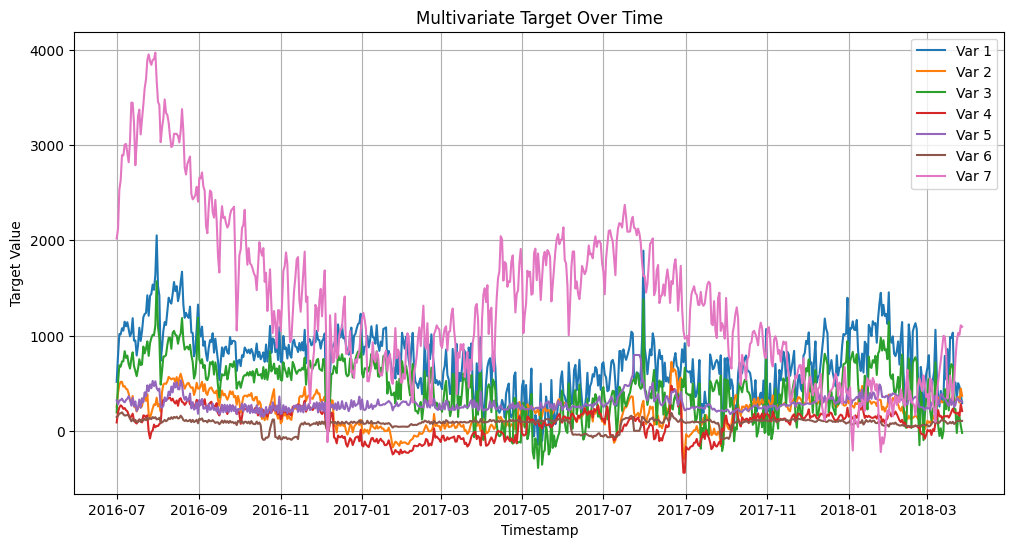

item_0
D
2016-07-01
(7, 665)
[[702.821    991.301    772.209    597.123    703.549   ]
 [ 79.03      99.995    175.279    207.303    185.456   ]
 [348.883    639.671    439.351    279.375    380.22    ]
 [-75.411    -48.182     13.608     54.546     18.19    ]
 [350.397    347.11     327.768    317.017    323.474   ]
 [110.236     95.609    105.661    110.256996 116.198   ]
 [885.033    457.187    691.442    845.994    962.627   ]]


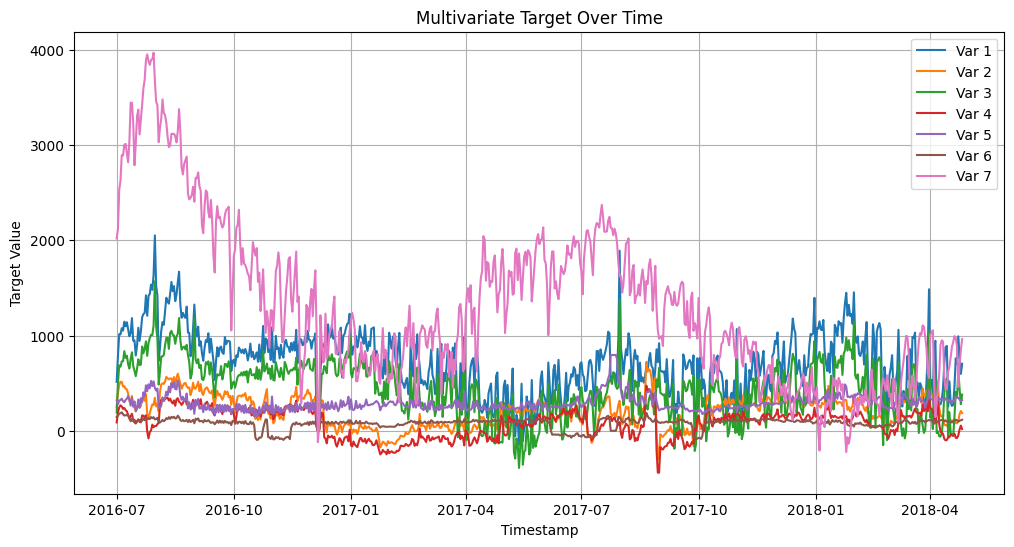

item_0
D
2016-07-01
(7, 695)
[[ 846.827     222.97899   423.649     679.911     892.708   ]
 [ 302.618     359.144     315.205     324.85      379.57098 ]
 [ 552.64     -108.699005   72.312996  349.985     518.384   ]
 [ 160.22      189.76      147.539     162.001     178.209   ]
 [ 288.662     322.555     336.513     320.73898   366.268   ]
 [  93.105     115.159     117.968     119.189     149.46    ]
 [ 671.323     877.932     896.993     787.32      820.172   ]]


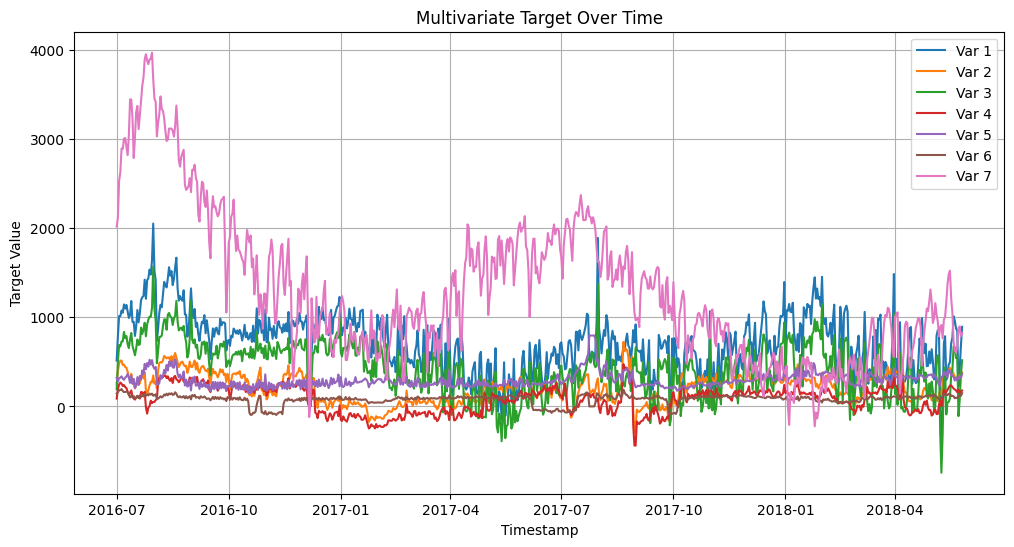

In [ ]:
import pandas as pd

for data in tqdm(dataset):
    print(data["item_id"])
    print(data["freq"])
    print(data["start"])
    print(data["target"].shape)
    print(data["target"][:,-5:])
    import matplotlib.pyplot as plt

    # Generate timestamps based on the start date and frequency
    timestamps = pd.date_range(start=data["start"].to_timestamp(), periods=data["target"].shape[1], freq=data["freq"])
    plt.figure(figsize=(12, 6))
    # Plot each variate
    for i, variate in enumerate(data["target"], start=1):
        plt.plot(timestamps, variate, label=f'Var {i}')

    plt.xlabel("Timestamp")
    plt.ylabel("Target Value")
    plt.title("Multivariate Target Over Time")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
h = pipeline.predictor.h or dataset.test_data.prediction_length
freq = pipeline.predictor.freq
print(h, freq, pipeline.predictor.batch_size)

30 None 1024


### forecasts is a list of size n_dataset x n_variate, where variates come consequently, each item of shape n_quantiles (10 here) x h (30 here)

In [ ]:
for forecast in evaluator.forecasts:
    print(forecast.start_date)
    print(forecast.forecast_array.shape)
    

AttributeError: 'Evaluator' object has no attribute 'forecasts'

In [ ]:
batch = []
for _, entry in enumerate(dataset):
    batch.append(entry)

# So batch is w * n_var * T
len(batch), [wind['target'].shape for wind in batch]

(3, [(7, 635), (7, 665), (7, 695)])

In [ ]:
# Extract all values for each variate across all windows
variates = batch[0]['target'].shape[0]  # number of variates
windows = len(batch)

# var_i: all values of variate i from all windows concatenated
var_dict = {}
for i in range(variates):
    var_dict[f'var_{i+1}'] = [batch[w]['target'][i].flatten() for w in range(windows)]
    var_dict[f'var_{i+1}'] = np.concatenate(var_dict[f'var_{i+1}'])

# var_i_j: all values of variate i from window j (j=1-based)
for i in range(variates):
    for j in range(windows):
        var_dict[f'var_{i+1}_{j+1}'] = batch[j]['target'][i].flatten()

# Example: var_1 contains all values of variate 1 from all windows
#          var_1_1 contains all values of variate 1 from window 1

# Check if the first 2376 values of all windows are the same for each variate
same_across_windows = {}
for i in range(variates):
    key = f'var_{i+1}_1'
    reference = var_dict[key][:2376]
    all_equal = True
    for j in range(2, windows+1):
        compare_key = f'var_{i+1}_{j}'
        if not np.array_equal(reference, var_dict[compare_key][:2376]):
            all_equal = False
            break
    same_across_windows[f'var_{i+1}'] = all_equal

same_across_windows

{'var_1': False,
 'var_2': False,
 'var_3': False,
 'var_4': False,
 'var_5': False,
 'var_6': False,
 'var_7': False}

### Findings:
> 1. evaluator.dataset.test_data.input, which converts to the batch input, is in the shape of (n_windows, n_var, n_time_step), Each window and var contains all values of the previous window + 48 new time steps, which is the `h`
> 2. df is just all n_windows concatenated together vertically, each window with the same starting ds. So the number of rows of df = sum of all time steps in the (test) dataset. Multivariates are converted into y_i columns
> 3. predict_df takes df to run MedianEnsemble.forecast(), and returns fcst_df in the shape of (n_windows x n_var x h,  2 (unique_id, ds) + 1 (median) + 9 (quantiles)) or (6 x 7 x 48, 12)
> 4. Last bit of predict_df wrangles fcst_df to the shape of (n_windows x n_var, h) or (6 * 7, 48)

In [ ]:
df = pipeline.predictor._gluonts_dataset_to_df(batch)
df.shape

(1536, 9)

In [ ]:
df

,unique_id,ds,y_0,y_1,y_2,y_3,y_4,y_5,y_6
0,item_0-2018-07-29,2016-11-01,724.322998,78.234001,532.916016,120.461998,176.082001,-89.395996,1045.990967
1,item_0-2018-07-29,2016-11-02,717.957031,99.008003,527.767029,148.285004,184.589005,-88.847000,1328.925049
2,item_0-2018-07-29,2016-11-03,995.388000,219.499008,719.832031,232.507004,269.776001,-65.849998,1679.463013
3,item_0-2018-07-29,2016-11-04,857.677979,160.755997,652.247009,196.826996,206.330994,-75.598000,1729.339966
4,item_0-2018-07-29,2016-11-05,874.351013,176.024994,610.807007,200.876999,255.093002,-66.983002,1872.352051
...,...,...,...,...,...,...,...,...,...
1531,item_0-2018-11-26,2018-05-22,846.827026,302.618011,552.640015,160.220001,288.661987,93.105003,671.322998
1532,item_0-2018-11-26,2018-05-23,222.978989,359.144012,-108.699005,189.759995,322.554993,115.158997,877.932007
1533,item_0-2018-11-26,2018-05-24,423.648987,315.204987,72.312996,147.539001,336.513000,117.968002,896.992981
1534,item_0-2018-11-26,2018-05-25,679.911011,324.850006,349.984985,162.001007,320.738983,119.189003,787.320007


In [ ]:
metadata = pipeline.predictor.multivar_metadata if len(pipeline.predictor.target_cols) > 1 else pipeline.predictor.univar_metadata

In [ ]:
pipeline.predictor.univar_metadata

{'item_0-2018-07-29': {'item_id': 'item_0',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-09-27': {'item_id': 'item_0',
  'fcst_start': Period('2018-09-27', 'D')},
 'item_0-2018-11-26': {'item_id': 'item_0',
  'fcst_start': Period('2018-11-26', 'D')}}

In [ ]:
pipeline.predictor.multivar_metadata

{'item_0-2018-07-29_dim0': {'item_id': 'item_0_dim0',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim1': {'item_id': 'item_0_dim1',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim2': {'item_id': 'item_0_dim2',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim3': {'item_id': 'item_0_dim3',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim4': {'item_id': 'item_0_dim4',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim5': {'item_id': 'item_0_dim5',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-07-29_dim6': {'item_id': 'item_0_dim6',
  'fcst_start': Period('2018-07-29', 'D')},
 'item_0-2018-09-27_dim0': {'item_id': 'item_0_dim0',
  'fcst_start': Period('2018-09-27', 'D')},
 'item_0-2018-09-27_dim1': {'item_id': 'item_0_dim1',
  'fcst_start': Period('2018-09-27', 'D')},
 'item_0-2018-09-27_dim2': {'item_id': 'item_0_dim2',
  'fcst_start': Period('2018-09-27', 'D')},
 'item_0-2018-09-27_

In [ ]:
fcst_df = pipeline.predictor.forecaster.forecast(
            df=df,
            h=h,
            freq=freq,
            level=pipeline.predictor.level,
            quantiles=pipeline.predictor.quantiles,
        )

100%|██████████| 1/1 [00:02<00:00,  2.90s/it]


In [ ]:
fcst_df

,unique_id,ds,ToTo-GiftEval-sample,ToTo-GiftEval-sample-q-10,ToTo-GiftEval-sample-q-20,ToTo-GiftEval-sample-q-30,ToTo-GiftEval-sample-q-40,ToTo-GiftEval-sample-q-50,ToTo-GiftEval-sample-q-60,ToTo-GiftEval-sample-q-70,ToTo-GiftEval-sample-q-80,ToTo-GiftEval-sample-q-90
0,item_0-2018-07-29_dim0,2018-03-28,402.438538,133.776840,240.017746,293.472473,348.730042,402.438538,453.927185,498.796997,600.496033,746.577515
1,item_0-2018-07-29_dim0,2018-03-29,403.219910,166.116943,257.811462,306.457703,354.461090,403.219910,498.094543,570.685791,687.060425,823.501892
2,item_0-2018-07-29_dim0,2018-03-30,474.111633,134.471497,225.800262,341.376190,403.334717,474.111633,517.202332,581.310974,675.250732,813.590088
3,item_0-2018-07-29_dim0,2018-03-31,435.844727,98.818459,267.038361,322.408081,379.785339,435.844727,526.387756,583.158997,647.667297,769.253723
4,item_0-2018-07-29_dim0,2018-04-01,419.990540,146.089752,220.102371,294.044495,351.028412,419.990540,479.377380,534.845886,605.148193,700.662537
...,...,...,...,...,...,...,...,...,...,...,...,...
625,item_0-2018-11-26_dim6,2018-06-21,1292.558594,725.867432,959.891357,1091.161743,1174.439697,1292.558594,1346.848877,1499.520508,1627.024170,1736.846069
626,item_0-2018-11-26_dim6,2018-06-22,1308.072266,679.598633,1013.075134,1141.043091,1210.016357,1308.072266,1401.976562,1495.632568,1631.530029,1817.759033
627,item_0-2018-11-26_dim6,2018-06-23,1253.431763,681.210571,937.180115,1020.544006,1139.970825,1253.431763,1303.598022,1436.564331,1552.714111,1706.321655
628,item_0-2018-11-26_dim6,2018-06-24,1221.339111,618.435730,845.585999,984.929810,1134.170166,1221.339111,1387.773926,1512.767090,1638.398071,1799.036987


In [ ]:
fcst_df.shape

(630, 12)

In [ ]:
for input_data in iter(evaluator.dataset.univar_test_data.input):
    print(input_data["item_id"], input_data["start"], input_data["target"].shape)


item_0_dim0 2016-07-01 (635,)
item_0_dim0 2016-07-01 (665,)
item_0_dim0 2016-07-01 (695,)
item_0_dim1 2016-07-01 (635,)
item_0_dim1 2016-07-01 (665,)
item_0_dim1 2016-07-01 (695,)
item_0_dim2 2016-07-01 (635,)
item_0_dim2 2016-07-01 (665,)
item_0_dim2 2016-07-01 (695,)
item_0_dim3 2016-07-01 (635,)
item_0_dim3 2016-07-01 (665,)
item_0_dim3 2016-07-01 (695,)
item_0_dim4 2016-07-01 (635,)
item_0_dim4 2016-07-01 (665,)
item_0_dim4 2016-07-01 (695,)
item_0_dim5 2016-07-01 (635,)
item_0_dim5 2016-07-01 (665,)
item_0_dim5 2016-07-01 (695,)
item_0_dim6 2016-07-01 (635,)
item_0_dim6 2016-07-01 (665,)
item_0_dim6 2016-07-01 (695,)


In [ ]:
for forecast in evaluator.forecasts:
    print(forecast.item_id, forecast.start_date, forecast.forecast_array.shape)


AttributeError: 'Evaluator' object has no attribute 'forecasts'

In [ ]:
from collections import OrderedDict

# Example dictionary
data = {
    "item_0_dim0": 1,
    "item_0_dim1": 2,
    "item_0_dim2": 3,
    "item_1_dim0": 4,
    "item_1_dim1": 5,
    "item_1_dim2": 6,
}

# Extract the keys and group them by dimension
grouped = {}
for key in data.keys():
    item, dim = key.split("_dim")
    grouped.setdefault(dim, []).append(key)

# Flatten and reorder
flattened = OrderedDict()
for dim in sorted(grouped):  # Sort dimensions
    for key in grouped[dim]:  # Add items in order
        flattened[key] = data[key]

# Result
print(flattened)
print(list(flattened.keys()))



OrderedDict([('item_0_dim0', 1), ('item_1_dim0', 4), ('item_0_dim1', 2), ('item_1_dim1', 5), ('item_0_dim2', 3), ('item_1_dim2', 6)])
['item_0_dim0', 'item_1_dim0', 'item_0_dim1', 'item_1_dim1', 'item_0_dim2', 'item_1_dim2']


In [ ]:
grouped

{'0': ['item_0_dim0', 'item_1_dim0'],
 '1': ['item_0_dim1', 'item_1_dim1'],
 '2': ['item_0_dim2', 'item_1_dim2']}

In [ ]:
def align_items(forecasts, test_data):
    aligned_forecasts = []
    for test in iter(test_data.input):
        aligned_forecasts.append(forecasts[test["item_id"]])
    
    return aligned_forecasts

align_items(evaluator.forecasts, evaluator.dataset.univar_test_data)

TypeError: list indices must be integers or slices, not str

In [ ]:
from gluonts.model import evaluate_forecasts
from gluonts.ev.metrics import MASE


res = evaluate_forecasts(
    forecasts=evaluator.forecasts,
    test_data=evaluator.dataset.univar_test_data if to_univariate else evaluator.dataset.test_data,
    metrics=[MASE()],
    batch_size=pipeline.predictor.batch_size,
    axis=None,
    mask_invalid_label=True,
    allow_nan_forecast=False,
    seasonality=evaluator.seasonality,
)

0it [00:00, ?it/s]

ValueError: operands could not be broadcast together with shapes (3,7,30) (21,30) 

In [ ]:
fcst_df = fcst_df.set_index("unique_id")
fcsts: list[Forecast] = []
for uid, metadata_uid in tqdm(metadata.items(), total=len(metadata)):
    fcst_df_uid = fcst_df.loc[uid]
    forecast_arrays = ufp.value_cols_to_numpy(
        df=fcst_df_uid,
        id_col="unique_id",
        time_col="ds",
        target_col=None,
    )
    forecast_keys = ["mean"]
    if pipeline.predictor.quantiles is not None:
        forecast_keys += [f"{q}" for q in pipeline.predictor.quantiles]
    q_fcst = QuantileForecast(
        forecast_arrays=forecast_arrays.T,
        forecast_keys=forecast_keys,
        item_id=metadata_uid["item_id"],
        start_date=metadata_uid["fcst_start"],
    )
    fcsts.append(q_fcst)


  0%|          | 0/42 [00:00<?, ?it/s]

In [ ]:
fcsts.__len__(), fcsts[0].quantile(0.5).__len__()

(42, 48)

In [ ]:
fcsts_50qtl = [fcst.quantile(0.5) for fcst in fcsts]

In [ ]:
fcsts_arr = np.stack(fcsts)  # shape: (42, 48)

# Reshape to (6, 7, h)
fcsts_reshaped = fcsts_arr.reshape(6, 7, )
fcsts_reshaped.shape

(6, 7)

In [ ]:
fcsts_reshaped[0][0].quantile(0.5).shape

(48,)

## Evaluate

### Evaluation Pipeline Summary

1. **Batching Data and Forecasts**  
   The original data and forecasts are passed to `gluonts.model.evaluation.evaluate_forecasts_raw`, where `data.input`, `data.label`, and forecasts are parsed and grouped into batches using a batcher.

2. **Batch Wrapping with ChainMap**  
   For each batch, the input, label, and forecasts are combined into a `ChainMap` object called `data_batch`, which is basically a merged dictionary for convenient access and is then passed to each metric (e.g., MAE, MSE) for evaluation.

3. **Metric Calculation Process**  
   - Each metric is instantiated as an evaluator, and the calculation is performed via `evaluator.update(data_batch)`.
   - The evaluator has two main components:
     - `stat`: Defines the error calculation (e.g., `absolute_error` for MAE). A `partial` wrapper is used to fix parameters such as `forecast_type='0.5'`.
     - `aggregate`: Typically a `Mean()` class with a specified axis for aggregation.
   - Under the hood, `evaluator.update` executes `aggregate.step(stat(data))`:
     - `stat(data)` computes the error for the batch (e.g., `absolute_error(data_batch, forecast_type='0.5')`).
     - `aggregate.step()` processes the error and updates:
       - `aggregate.partial_result`: The sum of all errors in the batch.
       - `aggregate.get()`: The mean error, calculated as `aggregate.partial_result / aggregate.n`.

4. **Aggregating Results Across Batches**  
   As the evaluation iterates through all batches, the evaluator accumulates the total error (`partial_result`) and the total number of time steps (`n`). The final average error across all batches is obtained via `aggregate.get()`.

### Notes
1. For multivar data, metrics are calculated with all vars flattened into one - aggregated over all time steps. Make sense when the number of steps among vars are largely different

### Preproc

In [ ]:
from gluonts.ev.metrics import (
    MAE,
    MAPE,
    MASE,
    MSE,
    MSIS,
    ND,
    NRMSE,
    RMSE,
    SMAPE,
    MeanWeightedSumQuantileLoss,
)

from gluonts.itertools import batcher

from gluonts.model.evaluation import _get_data_batch
from toolz import first

In [ ]:
test_data = evaluator.dataset.test_data
# test_data = evaluator.dataset.univar_test_data
axis = None
metrics = [
    MAE(),
]

batch_size=512 # ?

# forecasts = fcsts_reshaped
forecasts = fcsts


EVALUATOR = Evaluator(
    dataset_name=dataset_cfg.get("name"),
    term=dataset_cfg.get("term", "short"),
    to_univariate=to_univariate,
    # Create a subdirectory for each model's results
    output_path=f"{pipeline.output_path}/{pipeline.forecaster.alias}",
    storage_path=pipeline.storage_path,
    config=pipeline.config
)

seasonality = EVALUATOR.seasonality
mask_invalid_label = True
allow_nan_forecast = False

In [ ]:
label_ndim = first(test_data.label)["target"].ndim

assert label_ndim in [1, 2]

if axis is None:
    axis = tuple(range(label_ndim + 1))
if isinstance(axis, int):
    axis = (axis,)

assert all(ax in range(3) for ax in axis)

evaluators = {}
evaluator_metric = MAE()(axis=axis)
evaluators[evaluator_metric.name] = evaluator_metric


index_data = []

# TODO: Here the returned batch size is actually just one, within which there are several windows. 
# We may want to align the batcher and the windows, or remove batcher altogether.
input_batches = batcher(test_data.input, batch_size=batch_size)
label_batches = batcher(test_data.label, batch_size=batch_size)
forecast_batches = batcher(forecasts, batch_size=batch_size)

# pbar = tqdm()

input_batch, label_batch, forecast_batch = first(zip(input_batches, label_batches, forecast_batches))

if 0 not in axis:
    index_data.extend(
        [
            (forecast.item_id, forecast.start_date)
            for forecast in forecast_batch
        ]
    )


data_batch = _get_data_batch(
            input_batch,
            label_batch,
            forecast_batch,
            seasonality=seasonality,
            mask_invalid_label=mask_invalid_label,
            allow_nan_forecast=allow_nan_forecast,
        )

In [ ]:
input_batch[0]['target'].shape

(2376,)

In [ ]:
label_batch[0]['target']

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.07666667,  0.74      ,  2.9758334 ,  3.04      ,  3.04      ,
        3.04      ,  3.04      ,  3.0016668 ,  2.58      ,  3.5       ,
        5.34      ,  5.34      ,  5.34      ,  5.34      ,  5.3075    ,
        4.95      ,  4.95      ,  4.7083335 ,  5.0641665 ,  5.6433334 ,
        5.67      ,  6.23      ,  6.62      ,  7.25      , 10.098333  ,
       10.315     , 11.218333  , 11.948334  , 12.        , 13.494166  ,
       14.37      , 15.315     , 15.64      , 16.066668  , 16.22      ,
       17.3925    , 17.485834  , 17.91      , 18.26      , 18.251667  ,
       18.581667  , 19.09      , 19.284166  ], dtype=float32)

In [ ]:
from gluonts.time_feature.seasonality import get_seasonality
from gluonts.ev.ts_stats import seasonal_error

label_target = np.stack([label["target"] for label in label_batch], axis=0)
if mask_invalid_label:
    label_target = np.ma.masked_invalid(label_target)

# input_target_stack = np.stack([input_["target"] for input_ in input_batch], axis=0)
input_target = [input_["target"] for input_ in input_batch]
# if mask_invalid_label:
#     input_target = np.ma.masked_invalid(input_target)

other_data = {
    "label": label_target,
    "input": input_target,
}

seasonal_error_values = []
for input_ in input_batch:
    seasonality_entry = seasonality
    if seasonality_entry is None:
        seasonality_entry = get_seasonality(input_["start"].freqstr)
    input_target = input_["target"]
    if mask_invalid_label:
        input_target = np.ma.masked_invalid(input_target)
    seasonal_error_values.append(
        seasonal_error(
            input_target,
            seasonality=seasonality_entry,
            time_axis=-1,
        )
    )
other_data["seasonal_error"] = np.array(seasonal_error_values)


In [ ]:
from gluonts.model.evaluation import BatchForecast

data_batch_forecast = BatchForecast(forecast_batch, False)

In [ ]:
# ChainMap is a class from Python’s collections module 
# that groups multiple dictionaries (or mappings) together to be treated as a single, updateable view. 
# When you search for a key, it looks through each dictionary in order until it finds the key.
from collections import ChainMap

dict1 = {'a': 1, 'b': 2}
dict2 = {'b': 3, 'c': 4}

cm = ChainMap(dict1, dict2)
print(cm['b'])  # Output: 2 (from dict1)
print(cm['c'])  # Output: 4 (from dict2)

2
4


### Metric Update

In [ ]:
data_batch['label'].data.shape, data_batch['input'].__len__(), data_batch['input'][0].shape

((42, 48), 42, (2376,))

In [ ]:
# Calculate the mean of each array in 'input'
input_means = np.array([arr.mean() for arr in other_data['input']])

# Subtract the mean from each corresponding array in label.data
label_minus_input_mean = np.array([label_arr - mean for label_arr, mean in zip(data_batch['label'], input_means)])

# label_minus_input_mean will be a (42, N) array, where N is the length of each label array
label_minus_input_mean.shape, label_minus_input_mean

((42, 48),
 array([[-16.126362 , -16.126362 , -16.126362 , ...,   2.455305 ,
           2.9636383,   3.1578045],
        [  3.6130495,   3.6855497,   4.1738825, ...,   8.364715 ,
           8.3388815,   8.455548 ],
        [  8.567972 ,   8.642971 ,   8.739637 , ...,   9.094639 ,
           9.094639 ,   9.094639 ],
        ...,
        [-24.538095 , -24.538095 , -24.538095 , ...,   4.0452385,
           5.6285706,   9.128572 ],
        [ 12.271969 ,   9.521969 ,   9.938637 , ...,  20.771969 ,
          20.1053   ,  20.1053   ],
        [ 20.603819 ,  23.770483 ,  21.020483 , ...,  27.103819 ,
          19.770483 ,  15.437151 ]], dtype=float32))

In [ ]:
np.abs(data_batch['label'] - input_means[:, None])

masked_array(
  data=[[16.126361846923828, 16.126361846923828, 16.126361846923828, ...,
         2.4553050994873047, 2.9636383056640625, 3.157804489135742],
        [3.6130495071411133, 3.685549736022949, 4.173882484436035, ...,
         8.364714622497559, 8.338881492614746, 8.455548286437988],
        [8.567972183227539, 8.64297103881836, 8.73963737487793, ...,
         9.09463882446289, 9.09463882446289, 9.09463882446289],
        ...,
        [24.538095474243164, 24.538095474243164, 24.538095474243164, ...,
         4.045238494873047, 5.628570556640625, 9.128572463989258],
        [12.271968841552734, 9.521968841552734, 9.938636779785156, ...,
         20.771968841552734, 20.105300903320312, 20.105300903320312],
        [20.603818893432617, 23.770483016967773, 21.020483016967773, ...,
         27.103818893432617, 19.770483016967773, 15.437150955200195]],
  mask=[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, 

In [ ]:
# Breaking this down:
MAE()().update(data_batch)

DirectMetric(name='MAE[0.5]', stat=functools.partial(<function absolute_error at 0x700ff1d5f420>, forecast_type='0.5'), aggregate=Mean(axis=None, partial_result=array(14139.86379857), n=2016))

In [ ]:
from gluonts.ev.stats import absolute_error

from gluonts.ev.metrics import DirectMetric
from gluonts.ev.aggregations import Mean
from functools import partial


In [ ]:
# partial allows you to fix a certain number of arguments of a function and generate a new function.
# Here, we are fixing the forecast_type argument of absolute_error to '0.5'
stat = partial(absolute_error, forecast_type='0.5')
aggregate = Mean(axis=axis)

In [ ]:
mae = DirectMetric(
            name=f"MAE['0.5']",
            stat=stat,
            aggregate=aggregate,
        )

In [ ]:
error_batch = stat(data_batch)
# equivalent to: error_batch = np.abs(data_batch['label'] - data_batch['0.5'])

In [ ]:
stat(data_batch) == absolute_error(data_batch, forecast_type='0.5')

masked_array(
  data=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  mask=False,
  fill_value=True)

In [ ]:
aggregate.step(error_batch)

In [ ]:
print(aggregate.partial_result == sum(sum(error_batch.data)))
print(aggregate.get() == aggregate.partial_result / aggregate.n)

True
True


In [ ]:
aggregate.n

array(2016.)

In [ ]:
2016/42

48.0

In [ ]:
evaluator_metric.update(data_batch)

DirectMetric(name='MAE[0.5]', stat=functools.partial(<function absolute_error at 0x7651374e6d40>, forecast_type='0.5'), aggregate=Mean(axis=(0, 1), partial_result=array(71368.07279547), n=array(14112.)))

In [ ]:
evaluator_metric.aggregate.partial_result, evaluator_metric.aggregate.n, evaluator_metric.aggregate.get()

(array(71368.07279547), array(14112.), 5.0572613942370355)

In [ ]:
print(evaluator_metric.get() == aggregate.get())

True


### Custom Metrics

In [ ]:
MAR(context_length=512)(axis=axis).update(data_batch).get()

TypeError: MAR.__init__() got an unexpected keyword argument 'context_length'

In [ ]:
MAE()

MAE(forecast_type='0.5')

In [ ]:
MAE()()

DirectMetric(name='MAE[0.5]', stat=functools.partial(<function absolute_error at 0x716c61b3b240>, forecast_type='0.5'), aggregate=Mean(axis=None, partial_result=None, n=None))

In [ ]:
MSE(forecast_type='0.5')

MSE(forecast_type='0.5')

In [ ]:
MBR(forecast_type='0.5')

MBR(forecast_type='0.5')